In [41]:
import pandas as pd
import os
import numpy as np

from pathlib import Path

ROOT_DIR = Path(os.getcwd()).parent

In [42]:
df = pd.read_parquet(os.path.join(ROOT_DIR, "data/data_transformed.parquet"))
df = df.drop(columns=["ticker"])
df.head()

,chi2_stat_max_100_H,chi2_stat_mean_100_H,hour_0-3_max_100_H,hour_0-3_mean_100_H,hour_12-15_max_100_H,hour_12-15_mean_100_H,hour_15-18_max_100_H,hour_15-18_mean_100_H,hour_18-21_max_100_H,hour_18-21_mean_100_H,...,weekday_3_mean_9_H,weekday_4_max_9_H,weekday_4_mean_9_H,weekday_5_max_9_H,weekday_5_mean_9_H,weekday_6_max_9_H,weekday_6_mean_9_H,weekday_7_max_9_H,weekday_7_mean_9_H,is_pumped
0,74.390319,68.406267,0.645225,3.387396e-01,7.368040e-16,-6.312227e-14,0.000000,-3.411133e-15,0.000000,-5.734822e-16,...,-3.791417e-13,0.218907,0.175315,0.293696,2.352105e-01,0.487396,0.390337,0.000000,5.736200e-15,False
0,78.656428,71.144883,0.000000,0.000000e+00,2.236370e-01,2.085928e-01,0.000000,-4.961964e-15,1.000000,7.914072e-01,...,6.101015e-14,0.221096,0.205108,0.262590,2.436021e-01,0.115467,0.107117,0.000000,0.000000e+00,False
0,60.494432,57.659478,0.000000,1.317178e-14,0.000000e+00,7.780120e-14,0.190513,1.616115e-01,0.000000,1.940897e-14,...,6.509241e-01,0.089570,0.089570,0.130909,1.309093e-01,0.044719,0.044719,0.040657,4.065678e-02,False
0,70.396744,69.801410,0.000000,1.527099e-14,2.889589e-01,2.795163e-01,0.000000,-4.575685e-14,0.213881,2.068922e-01,...,1.364072e-01,0.250682,0.222636,0.260885,2.316974e-01,0.138556,0.123055,0.027840,2.472488e-02,True
0,52.471887,50.332702,0.081814,7.450057e-02,0.000000e+00,8.364452e-16,0.737901,7.144770e-01,0.050202,4.571405e-02,...,0.000000e+00,0.818532,0.458367,0.000000,-1.880696e-14,0.181468,0.101620,0.000000,-2.294863e-15,False


In [43]:
df = df.convert_dtypes()
df.dtypes

d:\HSE\pumps_and_dumps\env\Lib\site-packages\pandas\core\dtypes\cast.py:1056: RuntimeWarning:

invalid value encountered in cast

d:\HSE\pumps_and_dumps\env\Lib\site-packages\pandas\core\dtypes\cast.py:1080: RuntimeWarning:

invalid value encountered in cast



chi2_stat_max_100_H     Float64
chi2_stat_mean_100_H    Float64
hour_0-3_max_100_H      Float64
hour_0-3_mean_100_H     Float64
hour_12-15_max_100_H    Float64
                         ...   
weekday_6_max_9_H       Float64
weekday_6_mean_9_H      Float64
weekday_7_max_9_H       Float64
weekday_7_mean_9_H      Float64
is_pumped               boolean
Length: 11425, dtype: object

In [22]:
df = df.dropna()

In [23]:
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from functools import partial
import xgboost as xgb

df = df.fillna(0)

df_train, df_test = train_test_split(df, train_size=0.7, stratify=df["is_pumped"], shuffle=True)
df_val, df_test = train_test_split(df_test, train_size=0.7, stratify=df_test["is_pumped"], shuffle=True)

(
    df_train["is_pumped"].value_counts(), 
    df_test["is_pumped"].value_counts(),
    df_val["is_pumped"].value_counts()
)

(is_pumped
 False    14791
 True        53
 Name: count, dtype: Int64,
 is_pumped
 False    1902
 True        7
 Name: count, dtype: Int64,
 is_pumped
 False    4437
 True       16
 Name: count, dtype: Int64)

In [10]:
def xgboost_objective(trial, dtrain: xgb.DMatrix, dval: xgb.DMatrix) -> float:

    params = {
        "objective": "binary:logistic",
        "learning_rate": trial.suggest_float("learning_rate", 0.1, 1, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 100),
        "gamma": trial.suggest_float("gamma", 0.01, 1),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1, 500),
        "eval_metric": ["logloss"],
        "device": "cuda:0",
        "tree_method": "hist",
    }


    evals_result = {}

    model = xgb.train(
        params=params,
        dtrain=dtrain,
        evals=[(dtrain, "train"), (dval, "val")],
        num_boost_round=10000, early_stopping_rounds=10,
        verbose_eval=False, evals_result=evals_result,
    )

    y_pred = model.predict(dval)
    y_pred = (y_pred > trial.suggest_float("threshold", 0.5, 1, log=True)).astype(int)

    f1 = f1_score(y_true=dval.get_label(), y_pred=y_pred, pos_label=1)

    return f1

In [24]:
dtrain = xgb.DMatrix(data=df_train.iloc[:, :-1], label=df_train["is_pumped"].astype(int))
dval = xgb.DMatrix(data=df_val.iloc[:, :-1], label=df_val["is_pumped"].astype(int))
dtest = xgb.DMatrix(data=df_test.iloc[:, :-1], label=df_test["is_pumped"].astype(int))

In [25]:
import optuna

study_xgboost = optuna.create_study(
    direction="maximize",
)

study_xgboost.optimize(
    partial(xgboost_objective, dtrain=dtrain, dval=dval),
    n_trials=100
)

[I 2024-02-13 20:21:55,958] A new study created in memory with name: no-name-f686c715-9fd4-4712-8b7c-7a6dd227dd29
[I 2024-02-13 20:22:03,961] Trial 0 finished with value: 0.43478260869565216 and parameters: {'learning_rate': 0.19755571017419488, 'max_depth': 36, 'gamma': 0.02723405580136369, 'scale_pos_weight': 108.1751680237244, 'threshold': 0.7704971293887665}. Best is trial 0 with value: 0.43478260869565216.
[I 2024-02-13 20:22:15,411] Trial 1 finished with value: 0.43478260869565216 and parameters: {'learning_rate': 0.10660812981324821, 'max_depth': 21, 'gamma': 0.5774277767527256, 'scale_pos_weight': 156.29776938815377, 'threshold': 0.52257549674432}. Best is trial 0 with value: 0.43478260869565216.
[I 2024-02-13 20:22:17,361] Trial 2 finished with value: 0.43478260869565216 and parameters: {'learning_rate': 0.9245912309157988, 'max_depth': 64, 'gamma': 0.9587822475159229, 'scale_pos_weight': 184.21577410393743, 'threshold': 0.7204479176832738}. Best is trial 0 with value: 0.43478

In [26]:
from optuna.visualization import plot_param_importances

plot_param_importances(study_xgboost)

In [27]:
xgboost_params = {
    "objective": "binary:logistic",
    "eval_metric": ["logloss"],
    "device": "cuda:0",
    "tree_method": "hist",
}

xgboost_params.update(
    study_xgboost.best_params
)

In [28]:
xgboost_model = xgb.train(
    params=xgboost_params,
    dtrain=dtrain,
    evals=[(dtrain, "train"), (dval, "val")],
    num_boost_round=5000, early_stopping_rounds=10,
    verbose_eval=True
)

d:\HSE\pumps_and_dumps\env\Lib\site-packages\xgboost\core.py:160: UserWarning:

[20:30:53] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "threshold" } are not used.




[0]	train-logloss:0.84417	val-logloss:0.84927
[1]	train-logloss:0.74513	val-logloss:0.75011
[2]	train-logloss:0.64227	val-logloss:0.64429
[3]	train-logloss:0.56457	val-logloss:0.56583
[4]	train-logloss:0.50572	val-logloss:0.50743
[5]	train-logloss:0.47072	val-logloss:0.47200
[6]	train-logloss:0.42701	val-logloss:0.42915
[7]	train-logloss:0.38490	val-logloss:0.38701
[8]	train-logloss:0.35599	val-logloss:0.35698
[9]	train-logloss:0.32258	val-logloss:0.32503
[10]	train-logloss:0.29445	val-logloss:0.29902
[11]	train-logloss:0.28360	val-logloss:0.28858
[12]	train-logloss:0.25553	val-logloss:0.26074
[13]	train-logloss:0.23368	val-logloss:0.23934
[14]	train-logloss:0.22154	val-logloss:0.22715
[15]	train-logloss:0.20115	val-logloss:0.20698
[16]	train-logloss:0.19289	val-logloss:0.19853
[17]	train-logloss:0.17963	val-logloss:0.18529
[18]	train-logloss:0.17046	val-logloss:0.17655
[19]	train-logloss:0.15791	val-logloss:0.16393
[20]	train-logloss:0.14601	val-logloss:0.15279
[21]	train-logloss:0.13

In [51]:
importances = xgboost_model.get_score(importance_type='gain')


pd.DataFrame({
    "feature": importances.keys(),
    "value": importances.values()
}).sort_values(by="value", ascending=False).head(20)

,feature,value
379,weekday_5_mean_38_H,5102.008789
214,weekday_2_mean_243_H,3796.708008
391,hour_0-3_mean_44_H,3339.106689
18,hour_15-18_max_120_H,2622.102783
82,hour_15-18_max_172_H,2140.416504
23,weekday_4_max_122_H,2043.845947
266,weekday_2_max_282_H,1921.289185
238,weekday_6_mean_264_H,1817.520264
387,weekday_2_max_40_H,1801.238525
130,hour_21-24_max_19_H,1666.286621


In [29]:
df_test["is_pumped"].value_counts()

is_pumped
False    1902
True        7
Name: count, dtype: Int64

In [30]:
study_xgboost.best_params

{'learning_rate': 0.23447807307141494,
 'max_depth': 3,
 'gamma': 0.413204628377768,
 'scale_pos_weight': 494.7687832673115,
 'threshold': 0.9972119282985815}

In [37]:
pred = xgboost_model.predict(
    dtest
)

y_pred = (pred > 0.5).astype(int)

In [38]:
import numpy as np

np.unique(y_pred, return_counts=True)

(array([0, 1]), array([1908,    1], dtype=int64))

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

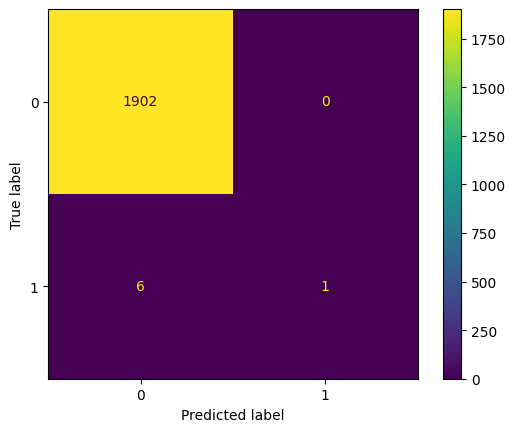

In [40]:
cm = confusion_matrix(y_pred=y_pred, y_true=df_test["is_pumped"].astype(int))

ConfusionMatrixDisplay(cm).plot()

In [36]:
print(
    classification_report(y_true=df_test["is_pumped"], y_pred=y_pred)
)

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1902
         1.0       1.00      0.14      0.25         7

    accuracy                           1.00      1909
   macro avg       1.00      0.57      0.62      1909
weighted avg       1.00      1.00      1.00      1909

